# Brain Tumor Detection

In [1]:
# import necessary libraries
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Input, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0, ResNet50, DenseNet121
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import random
import shutil
import json

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Kaggle dataset paths
BASE_DIR = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset'
TRAIN_DIR = os.path.join(BASE_DIR, 'Training')
TEST_DIR = os.path.join(BASE_DIR, 'Testing')

# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 64
NUM_CLASSES = 4
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
EPOCHS_PHASE1 = 10      # Phase 1: Train only the classification head
EPOCHS_PHASE2 = 20      # Phase 2: Fine-tune top 30% of base model

print(f"TensorFlow version: {tf.version}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")
print(f"Classes: {CLASS_NAMES}")

TensorFlow version: <module 'tensorflow._api.v2.version' from '/usr/local/lib/python3.12/dist-packages/tensorflow/_api/v2/version/__init__.py'>
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [2]:
# CREATE UNIFIED DATASET - SHUFFLE ALL IMAGES
# WHY: The original Training/ and Testing/ folders come from different sources.
# Shuffling all images together eliminates source bias and ensures fair evaluation.

UNIFIED_DIR = '/kaggle/working/unified_data'

if not os.path.exists(UNIFIED_DIR):
    print(" Creating unified dataset from all images...")
    os.makedirs(UNIFIED_DIR, exist_ok=True)
    for split in ['train', 'val', 'test']:
        for cls in CLASS_NAMES:
            os.makedirs(os.path.join(UNIFIED_DIR, split, cls), exist_ok=True)

    # Collect ALL images from both Training and Testing folders
    all_images, all_labels = [], []
    for cls in CLASS_NAMES:
        for path in [os.path.join(TRAIN_DIR, cls), os.path.join(TEST_DIR, cls)]:
            if os.path.exists(path):
                for img in os.listdir(path):
                    all_images.append(os.path.join(path, img))
                    all_labels.append(cls)

    print(f"Total images collected: {len(all_images)}")
    for cls in CLASS_NAMES:
        print(f"  {cls}: {all_labels.count(cls)}")

    # Split: 70% train, 15% val, 15% test (stratified by class)
    X_train, X_temp, y_train, y_temp = train_test_split(
        all_images, all_labels, test_size=0.3, stratify=all_labels, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
    )

    def copy_data(imgs, lbls, split):
        for img, lbl in zip(imgs, lbls):
            shutil.copy(img, os.path.join(UNIFIED_DIR, split, lbl))

    copy_data(X_train, y_train, 'train')
    copy_data(X_val, y_val, 'val')
    copy_data(X_test, y_test, 'test')

    print(" Unified dataset created successfully!")
    print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
else:
    print(" Unified dataset already exists.")

 Creating unified dataset from all images...
Total images collected: 7200
  glioma: 1800
  meningioma: 1800
  notumor: 1800
  pituitary: 1800
 Unified dataset created successfully!
Train: 5040, Val: 1080, Test: 1080


In [3]:
# DATA GENERATORS WITH AUGMENTATION
# WHY: Moderate augmentation improves generalization without distorting tumors.

train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,           # EfficientNetB0 expects [0, 255] input with preprocess_input
    rotation_range=18,           # Slight rotation for variability
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# No augmentation for validation and test
test_datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = train_datagen.flow_from_directory(
    os.path.join(UNIFIED_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

validation_generator = test_datagen.flow_from_directory(
    os.path.join(UNIFIED_DIR, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(UNIFIED_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

print(f"Train: {train_generator.samples}")
print(f"Validation: {validation_generator.samples}")
print(f"Test: {test_generator.samples}")
print(f"Class indices: {train_generator.class_indices}")

Found 5040 images belonging to 4 classes.
Found 1080 images belonging to 4 classes.
Found 1080 images belonging to 4 classes.
Train: 5040
Validation: 1080
Test: 1080
Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [4]:
# BUILD EFFICIENTNETB0 WITH LAMBDA PREPROCESSING
# WHY: Lambda layer forces correct preprocessing inside the model graph.

def build_efficientnetb0():
    inputs = Input(shape=(224, 224, 3))
    
    # Lambda preprocessing: convert [0,1] -> [0,255] -> EfficientNet preprocessing
    x = layers.Lambda(lambda x: x * 255.0)(inputs)
    x = layers.Lambda(lambda x: eff_preprocess(x))(x)
    
    # Base model (pre-trained on ImageNet)
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False
    x = base_model(x)
    
    # Classification head with regularization
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model, base_model

model, base_model = build_efficientnetb0()
model.summary()
print(" Model built successfully!")

I0000 00:00:1785342421.216434      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785342421.219318      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417,063 (16.85 MB)

 Trainable params: 364,420 (1.39 MB)

 Non-trainable params: 4,052,643 (15.46 MB)

 Model built successfully!


In [5]:
# PHASE 1: TRAIN CLASSIFICATION HEAD ONLY
# WHY: The base model is frozen. We only train the newly added Dense layers.
# Learning rate: 1e-3 (aggressive, since only ~300K parameters are trainable)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(" PHASE 1: Training Classification Head (10 epochs)")

history1 = model.fit(
    train_generator,
    epochs=EPOCHS_PHASE1,
    validation_data=validation_generator,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

# PHASE 2: FINE-TUNE TOP 30% OF BASE MODEL
# WHY: Unfreezing the top layers allows the model to adapt its high-level
# features to MRI data. Lower learning rate (1e-4) prevents catastrophic forgetting.

print(" PHASE 2: Fine-Tuning Top 30% of EfficientNetB0 (20 epochs)")

# Unfreeze the base model
base_model.trainable = True

# Freeze the first 70% of layers (keep bottom layers frozen)
# EfficientNetB0 has ~237 layers; we freeze the first 165
for layer in base_model.layers[:165]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_generator,
    epochs=EPOCHS_PHASE2,
    validation_data=validation_generator,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

print(" Training complete! Best model saved as 'best_model.h5'")

 PHASE 1: Training Classification Head (10 epochs)
Epoch 1/10


2026-07-29 16:27:28.009788: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-29 16:27:28.166005: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-29 16:27:28.566070: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-29 16:27:28.708161: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-29 16:27:29.523394: E external/local_xla/xla/stream_

69/79 ━━━━━━━━━━━━━━━━━━━━ 7s 716ms/step - accuracy: 0.6377 - loss: 0.9622

2026-07-29 16:28:35.269091: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-29 16:28:35.418577: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-29 16:28:35.789521: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-29 16:28:35.930518: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-29 16:28:36.714193: E external/local_xla/xla/stream_

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 923ms/step - accuracy: 0.6497 - loss: 0.9303

...


Epoch 9: finished saving model to best_model.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 60s 759ms/step - accuracy: 0.9639 - loss: 0.0980 - val_accuracy: 0.9704 - val_loss: 0.0853 - learning_rate: 1.0000e-04
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 712ms/step - accuracy: 0.9641 - loss: 0.0968
Epoch 10: val_accuracy improved from 0.97037 to 0.97500, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 60s 754ms/step - accuracy: 0.9655 - loss: 0.0935 - val_accuracy: 0.9750 - val_loss: 0.0721 - learning_rate: 1.0000e-04
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 718ms/step - accuracy: 0.9691 - loss: 0.0877
Epoch 11: val_accuracy improved from 0.97500 to 0.97963, saving model to best_model.h5



Epoch 11: finished saving model to best_model.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 60s 760ms/step - accuracy: 0.9692 - loss: 0.0895 - val_accuracy: 0.9796 - val_loss: 0.0632 - learning_rate: 1.0000e-04
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 718ms/step - accuracy: 0.9749 - loss: 0.0708
Epoch 12: val_accuracy did not improve from 0.97963
79/79 ━━━━━━━━━━━━━━━━━━━━ 60s 753ms/step - accuracy: 0.9756 - loss: 0.0684 - val_accuracy: 0.9769 - val_loss: 0.0577 - learning_rate: 1.0000e-04
Epoch 13/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 723ms/step - accuracy: 0.9744 - loss: 0.0707
Epoch 13: val_accuracy improved from 0.97963 to 0.98056, saving model to best_model.h5



Epoch 13: finished saving model to best_model.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 61s 767ms/step - accuracy: 0.9756 - loss: 0.0705 - val_accuracy: 0.9806 - val_loss: 0.0547 - learning_rate: 1.0000e-04
Epoch 14/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.9746 - loss: 0.0569
Epoch 14: val_accuracy did not improve from 0.98056
79/79 ━━━━━━━━━━━━━━━━━━━━ 60s 754ms/step - accuracy: 0.9768 - loss: 0.0571 - val_accuracy: 0.9806 - val_loss: 0.0558 - learning_rate: 1.0000e-04
Epoch 15/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 705ms/step - accuracy: 0.9816 - loss: 0.0483
Epoch 15: val_accuracy improved from 0.98056 to 0.98241, saving model to best_model.h5



Epoch 15: finished saving model to best_model.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 59s 745ms/step - accuracy: 0.9823 - loss: 0.0484 - val_accuracy: 0.9824 - val_loss: 0.0517 - learning_rate: 1.0000e-04
Epoch 16/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 720ms/step - accuracy: 0.9841 - loss: 0.0503
Epoch 16: val_accuracy did not improve from 0.98241
79/79 ━━━━━━━━━━━━━━━━━━━━ 60s 754ms/step - accuracy: 0.9823 - loss: 0.0523 - val_accuracy: 0.9796 - val_loss: 0.0502 - learning_rate: 1.0000e-04
Epoch 17/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.9817 - loss: 0.0568
Epoch 17: val_accuracy did not improve from 0.98241
79/79 ━━━━━━━━━━━━━━━━━━━━ 60s 755ms/step - accuracy: 0.9817 - loss: 0.0516 - val_accuracy: 0.9815 - val_loss: 0.0462 - learning_rate: 1.0000e-04
Epoch 18/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 718ms/step - accuracy: 0.9895 - loss: 0.0358
Epoch 18: val_accuracy did not improve from 0.98241
79/79 ━━━━━━━━━━━━━━━━━━━━ 59s 751ms/step - accuracy: 0.9871 - loss: 0.0401 - val_accuracy: 0.9

In [6]:
# BUILD ENSEMBLE MODELS
# Reuse the trained EfficientNetB0 from memory.
print(" BUILDING ENSEMBLE MODELS")

# 1. REUSE THE TRAINED EFFICIENTNETB0
# The variable 'model' is already in memory with 98% validation accuracy.
effnet_model = model 
print(f" EfficientNetB0 loaded from memory (val_acc: {max(history2.history['val_accuracy']):.4f})")

# 2. BUILD RESNET50 
def build_resnet50():
    inputs = Input(shape=(224, 224, 3))
    x = layers.Lambda(lambda x: x * 255.0)(inputs)
    x = layers.Lambda(lambda x: resnet_preprocess(x))(x)
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base.trainable = False
    x = base(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs)

# 3. BUILD DENSENET121 
def build_densenet121():
    inputs = Input(shape=(224, 224, 3))
    x = layers.Lambda(lambda x: x * 255.0)(inputs)
    x = layers.Lambda(lambda x: densenet_preprocess(x))(x)
    base = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base.trainable = False
    x = base(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs)

# Instantiate the other models
resnet_model = build_resnet50()
densenet_model = build_densenet121()

print(" ResNet50 and DenseNet121 built successfully!")
print(" Ensemble composition: EfficientNetB0 (trained) + ResNet50 + DenseNet121")

 BUILDING ENSEMBLE MODELS
 EfficientNetB0 loaded from memory (val_acc: 0.9824)
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 ResNet50 and DenseNet121 built successfully!
 Ensemble composition: EfficientNetB0 (trained) + ResNet50 + DenseNet121


In [7]:
# TRAIN RESNET50 & DENSENET121
# to provide complementary features to EfficientNetB0.

def quick_train(model, model_name, epochs=8):
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    print(f" Training {model_name} for {epochs} epochs...")
    history = model.fit(
        train_generator,
        epochs=epochs,
        validation_data=validation_generator,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )
    return model, history

# Train ResNet50
resnet_model, _ = quick_train(resnet_model, "ResNet50", epochs=8)

# Train DenseNet121
densenet_model, _ = quick_train(densenet_model, "DenseNet121", epochs=8)

print(" All ensemble models are now trained!")

 Training ResNet50 for 8 epochs...
Epoch 1/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 92s 970ms/step - accuracy: 0.7940 - loss: 0.7059 - val_accuracy: 0.8148 - val_loss: 0.4689 - learning_rate: 0.0010
Epoch 2/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 60s 758ms/step - accuracy: 0.8591 - loss: 0.4522 - val_accuracy: 0.8528 - val_loss: 0.3765 - learning_rate: 0.0010
Epoch 3/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.8814 - loss: 0.3420
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
79/79 ━━━━━━━━━━━━━━━━━━━━ 60s 758ms/step - accuracy: 0.8853 - loss: 0.3325 - val_accuracy: 0.8796 - val_loss: 0.3244 - learning_rate: 0.0010
Epoch 4/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 61s 770ms/step - accuracy: 0.8944 - loss: 0.2793 - val_accuracy: 0.9111 - val_loss: 0.2330 - learning_rate: 5.0000e-04
Epoch 5/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 61s 775ms/step - accuracy: 0.9127 - loss: 0.2373 - val_accuracy: 0.9185 - val_loss: 0.2050 - learning_rate: 5.0000e-04
Epoch 6/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 735ms/

 RUNNING ENSEMBLE PREDICTION ON TEST SET
 FINAL ENSEMBLE RESULTS
 Accuracy:  0.9639 (96.39%)
 Precision: 0.9642
 Recall:    0.9639
 F1-Score:  0.9636

 Detailed Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.96      0.97       270
  meningioma       0.96      0.91      0.93       270
     notumor       0.97      0.99      0.98       270
   pituitary       0.94      1.00      0.97       270

    accuracy                           0.96      1080
   macro avg       0.96      0.96      0.96      1080
weighted avg       0.96      0.96      0.96      1080



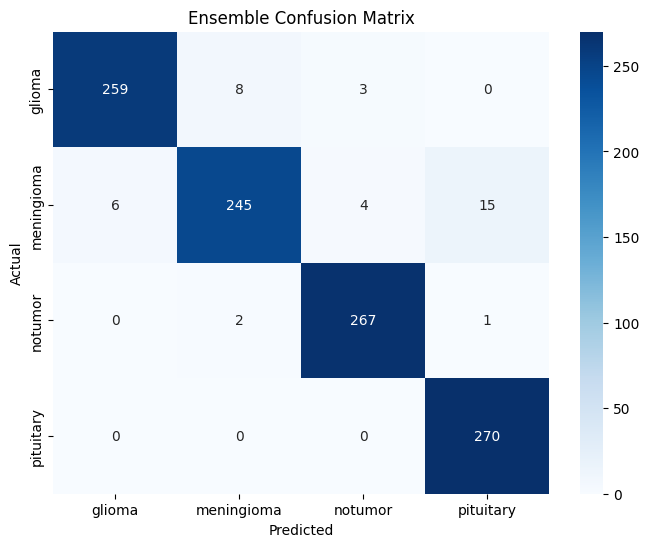

In [8]:
# WEIGHTED ENSEMBLE EVALUATION
# WHY: Weighted averaging leverages the strengths of each model.
# EfficientNetB0 (98% val_acc) gets the highest weight.
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report, confusion_matrix 

def ensemble_predict(models, weights, generator):
    """Weighted ensemble prediction."""
    generator.reset()
    all_probs = []
    
    for model, weight in zip(models, weights):
        probs = model.predict(generator, verbose=0)
        all_probs.append(probs * weight)
    
    # Weighted average
    ensemble_probs = np.sum(all_probs, axis=0) / sum(weights)
    return ensemble_probs

# Models and their weights
models = [effnet_model, resnet_model, densenet_model]
weights = [0.5, 0.25, 0.25]  # EfficientNetB0 gets 50% weight

print(" RUNNING ENSEMBLE PREDICTION ON TEST SET")

# Predict on test set
test_generator.reset()
ensemble_probs = ensemble_predict(models, weights, test_generator)
y_pred = np.argmax(ensemble_probs, axis=1)
y_true = test_generator.classes

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)

print(" FINAL ENSEMBLE RESULTS")
print(f" Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f" Precision: {precision_score(y_true, y_pred, average='weighted'):.4f}")
print(f" Recall:    {recall_score(y_true, y_pred, average='weighted'):.4f}")
print(f" F1-Score:  {f1_score(y_true, y_pred, average='weighted'):.4f}")
print("="*60)

# Classification Report
print("\n Detailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
plt.title('Ensemble Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()